In [3]:
print("Phishing Email Detection ML Project")
print("Python environment is working!")

Phishing Email Detection ML Project
Python environment is working!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("All libraries loaded successfully!")

Pandas: 2.2.3
NumPy: 2.2.1
Scikit-learn: 1.8.0
All libraries loaded successfully!


In [5]:
import pandas as pd

df = pd.read_csv("data/Phishing_Email.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 18650
Columns: 3


In [6]:
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [8]:
df["Email Type"].value_counts()

Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

In [9]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check for duplicate emails
print("Duplicate emails:", df["Email Text"].duplicated().sum())

# Remove duplicate emails
df = df.drop_duplicates(subset=["Email Text"])

# Reset the index
df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

Duplicate emails: 1112
Dataset shape after cleaning: (17538, 2)


In [10]:
df.head()

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [11]:
df["Email Type"].value_counts()

Email Type
Safe Email        10979
Phishing Email     6559
Name: count, dtype: int64

In [12]:
# Check the distribution of email types

email_counts = df["Email Type"].value_counts()

print(email_counts)

Email Type
Safe Email        10979
Phishing Email     6559
Name: count, dtype: int64


In [13]:
# Calculate percentage distribution

email_percentages = df["Email Type"].value_counts(normalize=True) * 100

print(email_percentages.round(2))

Email Type
Safe Email        62.6
Phishing Email    37.4
Name: proportion, dtype: float64


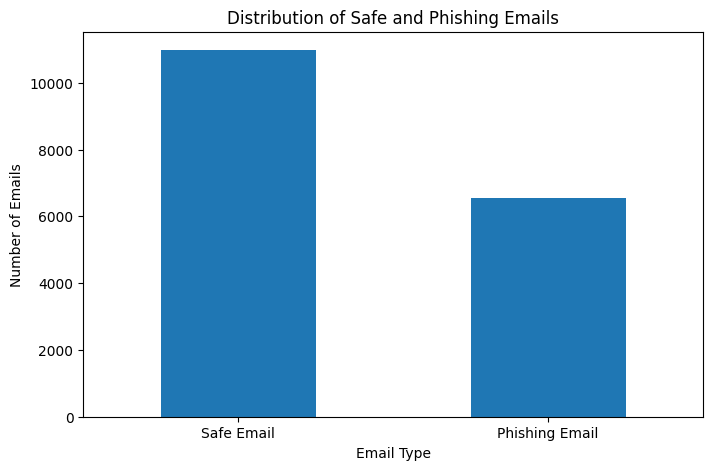

In [14]:
import matplotlib.pyplot as plt

email_counts = df["Email Type"].value_counts()

plt.figure(figsize=(8, 5))

email_counts.plot(kind="bar")

plt.title("Distribution of Safe and Phishing Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)

plt.show()

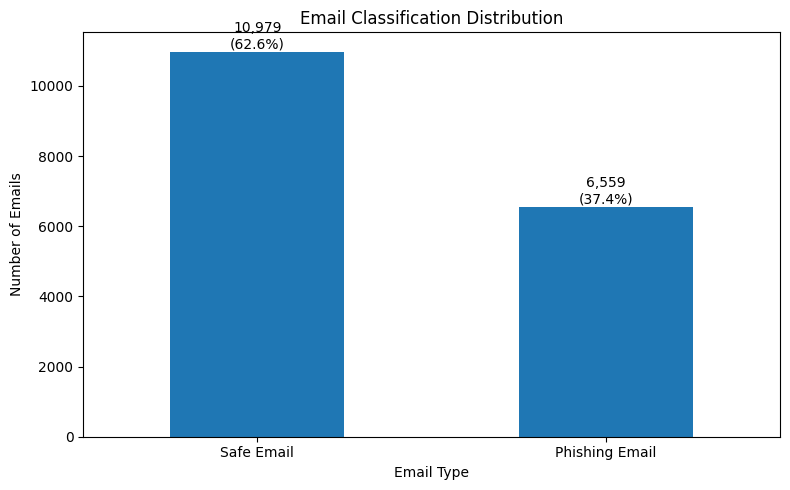

In [15]:
plt.figure(figsize=(8, 5))

ax = email_counts.plot(kind="bar")

plt.title("Email Classification Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)

for i, value in enumerate(email_counts):
    percentage = (value / len(df)) * 100
    ax.text(i, value + 100, f"{value:,}\n({percentage:.1f}%)",
            ha="center")

plt.tight_layout()
plt.show()

In [16]:
# Calculate the length of each email

df["Email Length"] = df["Email Text"].astype(str).apply(len)

df[["Email Text", "Email Type", "Email Length"]].head()

,Email Text,Email Type,Email Length
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,1030
1,the other side of * galicismos * * galicismo *...,Safe Email,479
2,re : equistar deal tickets are you still avail...,Safe Email,1245
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,688
4,software at incredibly low prices ( 86 % lower...,Phishing Email,441


In [17]:
df.groupby("Email Type")["Email Length"].mean()

Email Type
Phishing Email    1697.341058
Safe Email        3557.504235
Name: Email Length, dtype: float64

<Figure size 1000x600 with 0 Axes>

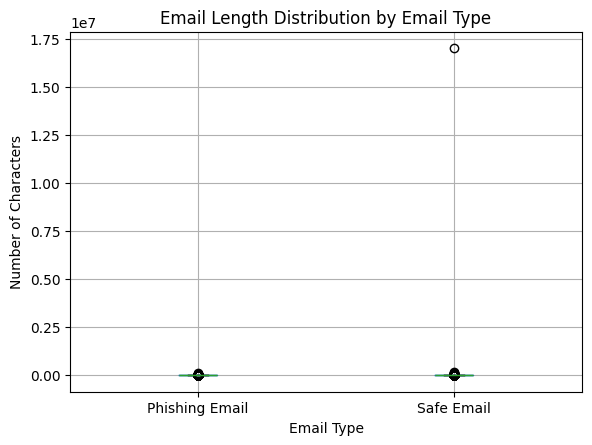

In [18]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="Email Length",
    by="Email Type"
)

plt.title("Email Length Distribution by Email Type")
plt.suptitle("")
plt.xlabel("Email Type")
plt.ylabel("Number of Characters")

plt.show()

In [19]:
df.isnull().sum()

Email Text      1
Email Type      0
Email Length    0
dtype: int64

In [23]:
import re

def clean_email(text):
    """
    Clean email text for machine learning.
    """
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [22]:
sample_email = df["Email Text"].iloc[0]

print("ORIGINAL EMAIL:")
print(sample_email)

print("\n" + "="*80 + "\n")

print("CLEANED EMAIL:")
print(clean_email(sample_email))

ORIGINAL EMAIL:
re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n't normally use ' brother ' in this way any more than we do 'd aughter ' , and it is hard to imagine a natural class comprising senior relatives and 's on ' but excluding ' brother ' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone 's attention , and hence at the beginning of an utterance , whereas 's on ' seems more natural in utterances like ' yes , son ' , ' hand me that , son ' than in ones like ' son ! ' or ' son , help me ! ' ( although perhaps these latter on

In [26]:
df["Cleaned Email"] = df["Email Text"].apply(clean_email)

In [27]:
df[["Email Text", "Cleaned Email", "Email Type"]].head()

,Email Text,Cleaned Email,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",re disc uniformitarianism re sex lang dick hud...,Safe Email
1,the other side of * galicismos * * galicismo *...,the other side of galicismos galicismo is a sp...,Safe Email
2,re : equistar deal tickets are you still avail...,re equistar deal tickets are you still availab...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,hello i am your hot lil horny toy i am the one...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,software at incredibly low prices lower draper...,Phishing Email


In [28]:
print("Original email:")
print(df["Email Text"].iloc[3])

print("\nCleaned email:")
print(df["Cleaned Email"].iloc[3])

Original email:

Hello I am your hot lil horny toy.
    I am the one you dream About,
    I am a very open minded person,
    Love to talk about and any subject.
    Fantasy is my way of life, 
    Ultimate in sex play.     Ummmmmmmmmmmmmm
     I am Wet and ready for you.     It is not your looks but your imagination that matters most,
     With My sexy voice I can make your dream come true...
  
     Hurry Up! call me let me Cummmmm for you..........................
TOLL-FREE:             1-877-451-TEEN (1-877-451-8336)For phone billing:     1-900-993-2582
-- 
_______________________________________________
Sign-up for your own FREE Personalized E-mail at Mail.com
http://www.mail.com/?sr=signup

Cleaned email:
hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet and ready for you it is not your looks but your imagination that matters most 

In [29]:
empty_emails = (df["Cleaned Email"].str.len() == 0).sum()

print("Empty emails after cleaning:", empty_emails)

Empty emails after cleaning: 4


In [30]:
# Remove emails that became empty after cleaning
df = df[df["Cleaned Email"].str.len() > 0].copy()

print("Dataset shape after removing empty emails:", df.shape)

Dataset shape after removing empty emails: (17534, 4)


In [31]:
# X = email text
# y = target label

X = df["Cleaned Email"]
y = df["Email Type"]

print("Features:", X.shape)
print("Labels:", y.shape)

Features: (17534,)
Labels: (17534,)


In [32]:
y = y.map({
    "Safe Email": 0,
    "Phishing Email": 1
})

print(y.value_counts())

Email Type
0    10978
1     6556
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14027
Testing samples: 3507


In [34]:
print(y.value_counts())

Email Type
0    10978
1     6556
Name: count, dtype: int64


In [38]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (14027, 5000)
Testing TF-IDF shape: (3507, 5000)


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform testing data
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (14027, 5000)
Testing TF-IDF shape: (3507, 5000)


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [40]:
# Make predictions on the test data
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 97.43 %


In [42]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Safe Email", "Phishing Email"]
))

Classification Report:
                precision    recall  f1-score   support

    Safe Email       0.97      0.99      0.98      2196
Phishing Email       0.98      0.96      0.97      1311

      accuracy                           0.97      3507
     macro avg       0.97      0.97      0.97      3507
  weighted avg       0.97      0.97      0.97      3507



Confusion Matrix:
[[2164   32]
 [  58 1253]]


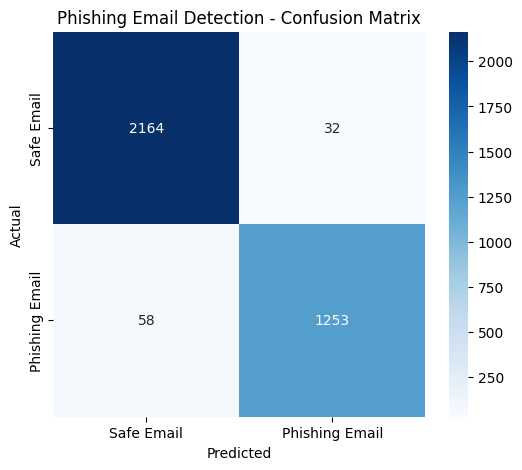

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualise confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe Email", "Phishing Email"],
    yticklabels=["Safe Email", "Phishing Email"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Phishing Email Detection - Confusion Matrix")
plt.show()

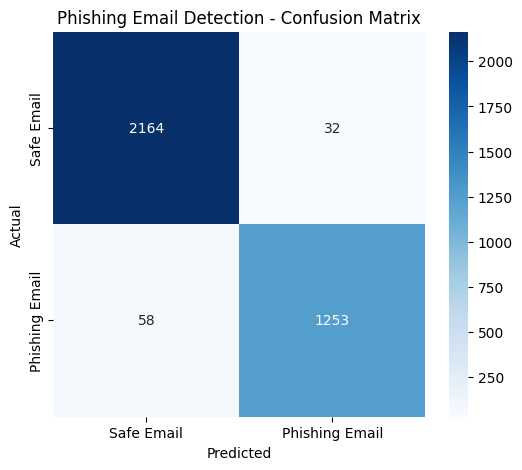

In [44]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe Email", "Phishing Email"],
    yticklabels=["Safe Email", "Phishing Email"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Phishing Email Detection - Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
# New emails for testing
new_emails = [
    "Congratulations! You have won a $1,000 prize. Click this link to claim your reward.",
    "Hi John, please find attached the meeting agenda for tomorrow's project meeting.",
    "Your account has been suspended. Verify your password immediately using the link below.",
    "Thank you for your order. Your package will be delivered tomorrow."
]

# Convert the new emails using the SAME TF-IDF vectorizer
new_emails_tfidf = tfidf.transform(new_emails)

# Make predictions
predictions = model.predict(new_emails_tfidf)

# Display results
for email, prediction in zip(new_emails, predictions):
    if prediction == 1:
        result = "PHISHING EMAIL"
    else:
        result = "SAFE EMAIL"
        
    print("Email:", email)
    print("Prediction:", result)
    print("-" * 80)

Email: Congratulations! You have won a $1,000 prize. Click this link to claim your reward.
Prediction: PHISHING EMAIL
--------------------------------------------------------------------------------
Email: Hi John, please find attached the meeting agenda for tomorrow's project meeting.
Prediction: SAFE EMAIL
--------------------------------------------------------------------------------
Email: Your account has been suspended. Verify your password immediately using the link below.
Prediction: PHISHING EMAIL
--------------------------------------------------------------------------------
Email: Thank you for your order. Your package will be delivered tomorrow.
Prediction: SAFE EMAIL
--------------------------------------------------------------------------------


In [46]:
# Get prediction probabilities
probabilities = model.predict_proba(new_emails_tfidf)

for email, prediction, probability in zip(
    new_emails,
    predictions,
    probabilities
):
    confidence = max(probability) * 100
    
    result = "PHISHING EMAIL" if prediction == 1 else "SAFE EMAIL"
    
    print("Email:", email)
    print("Prediction:", result)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 80)

Email: Congratulations! You have won a $1,000 prize. Click this link to claim your reward.
Prediction: PHISHING EMAIL
Confidence: 85.23 %
--------------------------------------------------------------------------------
Email: Hi John, please find attached the meeting agenda for tomorrow's project meeting.
Prediction: SAFE EMAIL
Confidence: 97.58 %
--------------------------------------------------------------------------------
Email: Your account has been suspended. Verify your password immediately using the link below.
Prediction: PHISHING EMAIL
Confidence: 59.14 %
--------------------------------------------------------------------------------
Email: Thank you for your order. Your package will be delivered tomorrow.
Prediction: SAFE EMAIL
Confidence: 59.59 %
--------------------------------------------------------------------------------


In [47]:
import ipywidgets as widgets
from IPython.display import display, clear_output

email_input = widgets.Textarea(
    value='',
    placeholder='Paste an email message here...',
    description='Email:',
    layout=widgets.Layout(width='80%', height='150px')
)

detect_button = widgets.Button(
    description='Detect Email',
    button_style='primary'
)

output = widgets.Output()

def detect_email(b):
    with output:
        clear_output()

        email = email_input.value.strip()

        if not email:
            print("Please enter an email message.")
            return

        # Convert email to TF-IDF features
        email_tfidf = tfidf.transform([email])

        # Prediction
        prediction = model.predict(email_tfidf)[0]

        # Probability
        probabilities = model.predict_proba(email_tfidf)[0]
        confidence = max(probabilities) * 100

        if prediction == 1:
            print("🚨 RESULT: PHISHING EMAIL")
        else:
            print("✅ RESULT: SAFE EMAIL")

        print("Confidence:", round(confidence, 2), "%")


detect_button.on_click(detect_email)

display(email_input)
display(detect_button)
display(output)

Textarea(value='', description='Email:', layout=Layout(height='150px', width='80%'), placeholder='Paste an ema…

Button(button_style='primary', description='Detect Email', style=ButtonStyle())

Output()

In [48]:
import joblib

# Save the trained model
joblib.dump(model, "phishing_email_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test data
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Safe Email", "Phishing Email"]
))

Model Accuracy: 97.43 %

Classification Report:
                precision    recall  f1-score   support

    Safe Email       0.97      0.99      0.98      2196
Phishing Email       0.98      0.96      0.97      1311

      accuracy                           0.97      3507
     macro avg       0.97      0.97      0.97      3507
  weighted avg       0.97      0.97      0.97      3507



In [50]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test data
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Safe Email", "Phishing Email"]
))

Model Accuracy: 97.43 %

Classification Report:
                precision    recall  f1-score   support

    Safe Email       0.97      0.99      0.98      2196
Phishing Email       0.98      0.96      0.97      1311

      accuracy                           0.97      3507
     macro avg       0.97      0.97      0.97      3507
  weighted avg       0.97      0.97      0.97      3507



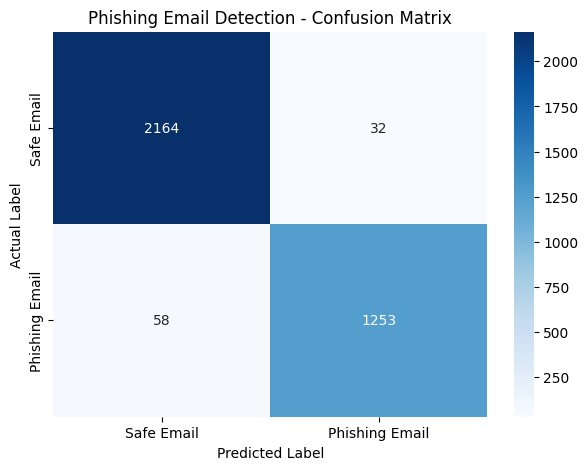

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe Email", "Phishing Email"],
    yticklabels=["Safe Email", "Phishing Email"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Phishing Email Detection - Confusion Matrix")

plt.show()

In [ ]:
# Get the words/features learned by the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Get the model coefficients
coefficients = model.coef_[0]

# Create a dataframe of features and their importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
})

# Most phishing-associated words
top_phishing = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

print("Top Phishing-Associated Features:")
display(top_phishing)

# Project Conclusion

This project developed a machine-learning-based phishing email detection system using natural language processing (NLP).

The email dataset was cleaned and prepared before being divided into training and testing datasets. TF-IDF (Term Frequency-Inverse Document Frequency) was used to convert email text into numerical features, including unigram and bigram features.

The trained model achieved an accuracy of **97.43%** on the test dataset.

## Model Performance

- Accuracy: **97.43%**
- Safe Email Precision: **97%**
- Safe Email Recall: **99%**
- Safe Email F1-score: **98%**
- Phishing Email Precision: **98%**
- Phishing Email Recall: **96%**
- Phishing Email F1-score: **97%**

The confusion matrix showed that the model correctly classified **2,164 safe emails** and **1,253 phishing emails**. It incorrectly classified 32 safe emails as phishing and missed 58 phishing emails.

## Security Significance

The project demonstrates how machine learning and natural language processing can be applied to cybersecurity to assist with phishing email detection.

The model can potentially support security teams by identifying suspicious email content and helping users prioritise potentially malicious messages for further investigation.

## Limitations

The model is trained on the dataset used in this project and may not perform identically on new or significantly different email datasets. Attackers can also modify phishing messages to avoid detection.

The 58 false-negative predictions demonstrate that further optimisation would be required before using the model in a real-world security environment.

## Future Improvements

Future versions could include:

- URL and domain analysis
- Sender reputation analysis
- Email header analysis
- Attachment analysis
- Detection of suspicious links
- More diverse training datasets
- Hyperparameter optimisation
- Testing additional machine-learning algorithms
- Integration with a SIEM or email security platform
- Deployment as a web-based phishing analysis tool

In [53]:
print(type(model).__name__)

LogisticRegression
